In [ ]:
# 读取文件夹结构
import os
# 指定路径
root_path = r"/Users/zhangnan/日常文件/ai/每周下载和预测/2 20250908/20250908-tas/20250908-tas 数据"
# 遍历文件夹结构
for root, dirs, files in os.walk(root_path):    
    print(f"当前文件夹: {root}")        
    # 判断是否有文件    
    if files:        
        display_files = files[:6]        
        print(f"  ✅ 文件数量: {len(files)}，展示前五个文件:")        
        for file in display_files:            
            print(f"    📄 {file}")    
        else:        
            print("  ⚠️ 该文件夹中没有文件")        
            if dirs:            
                print(f"  📁 包含的子文件夹: {', '.join(dirs)}")        
            else:            
                print("  ❌ 也没有子文件夹")    
        print()  # 空行用于分隔输出


In [ ]:
# 读取nc文件信息
import xarray as xr
# 定义文件路径
file_path = '/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas 数据/ERA5-monthly-single level-AZN-20260831.nc'
# 打印原文件路径
print(f"文件路径: {file_path}")
# 打开NetCDF文件
ds = xr.open_dataset(file_path)
# 输出数据集的基本信息
print(ds)
# 如果需要查看数据集的变量列表，可以使用
#print(ds.variables)
# 如果需要查看数据集的维度，可以使用
#print(ds.dims)


In [1]:
# 1 处理月最新数据
import xarray as xr
import numpy as np
import os

# 输入和输出路径
input_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/数据/download/ERA5-monthly-single level-AZN-20260831.nc"
output_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/merged_1.5deg_no_norm_20260831.nc"

# 自动创建输出目录
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# 打开数据集
ds = xr.open_dataset(input_path)

# 要处理的变量列表（根据你的数据变量）
variables = ["u10", "v10", "t2m", "msl", "sst"]

all_vars = {}
ref_grid = None
ref_time = None

for varname in variables:
    print(f"📥 正在处理变量: {varname}")
    var_data = ds[varname]

    # 降采样，步长6，约1.5度分辨率
    sub = var_data.isel(latitude=slice(None, None, 6), longitude=slice(None, None, 6))

    # 保存参考网格和时间
    if ref_grid is None:
        ref_grid = sub
        ref_time = sub.valid_time if "valid_time" in sub.coords else sub.time if "time" in sub.coords else None
    else:
        # 对齐空间和时间坐标
        sub = sub.interp_like(ref_grid)

    # 用全局平均填充 NaN
    values = sub.values
    mask = np.isnan(values)
    if np.any(mask):
        mean_val = np.nanmean(values)
        values[mask] = mean_val
        sub.values = values

    all_vars[varname] = sub

# 合并变量为Dataset
merged_ds = xr.Dataset(all_vars)

# 重命名时间维度为 time（如果是valid_time）
if "valid_time" in merged_ds.dims or "valid_time" in merged_ds.coords:
    merged_ds = merged_ds.rename({"valid_time": "time"})

# 清理重复时间索引
merged_ds = merged_ds.sortby("time")
merged_ds = merged_ds.sel(time=~merged_ds.get_index("time").duplicated())

# 保存
merged_ds.to_netcdf(output_path)
print(f"✅ 保存完毕: {output_path}")


📥 正在处理变量: u10
📥 正在处理变量: v10
📥 正在处理变量: t2m
📥 正在处理变量: msl
📥 正在处理变量: sst
✅ 保存完毕: /Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/merged_1.5deg_no_norm_20260831.nc


In [2]:
# 2 推理2026年6月的数据
import os
import torch
import xarray as xr
import numpy as np
from tqdm import tqdm
import torch.nn as nn

# === 路径与参数 ===
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/merged_1.5deg_no_norm_20260831.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/月模型/T2M&MSLP/climate_tcn_with_timeencoding_150_2month.pth"
OUTPUT_NC = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/预测结果-2026年8月.nc"
timesteps = 15
variables = ["u10", "v10", "sst", "t2m", "msl"]
target_names = ["t2m_pred", "msl_pred"]
device = torch.device("cpu")

# === 加载数据 ===
ds = xr.open_dataset(DATA_PATH)
time = ds.time.values
H, W = ds.dims["latitude"], ds.dims["longitude"]

# === 选择 2024-05 到 2025-07 的 15 个月 ===
sel_ds = ds.sel(time=slice("2025-05-01", "2026-07-01"))
assert sel_ds.dims["time"] == timesteps, f"时间维度应为15，实际为 {sel_ds.dims['time']}"

data_stack = np.stack([sel_ds[var].values for var in variables], axis=1)  # (15, 5, H, W)

# === 时间编码（sin/cos 月份）===
month = (sel_ds.time.dt.month.values - 1).astype(np.float32)
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin_2d = np.tile(month_sin[:, None, None, None], (1, 1, H, W))
month_cos_2d = np.tile(month_cos[:, None, None, None], (1, 1, H, W))
data_stack = np.concatenate([data_stack, month_sin_2d, month_cos_2d], axis=1)  # (15, 7, H, W)

# === 标准化前5个变量 ===
mean = data_stack[:, :5].mean(axis=(0, 2, 3), keepdims=True)
std = data_stack[:, :5].std(axis=(0, 2, 3), keepdims=True)
std[std == 0] = 1.0
data_stack[:, :5] = (data_stack[:, :5] - mean) / std

# === 扩展维度 ===
x = torch.tensor(data_stack[None, ...], dtype=torch.float32).to(device)  # (1, 15, 7, H, W)

# === 模型结构（与训练一致） ===
class ChEncoder(nn.Module):
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.spatial_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Linear(32 * 4 * 4, embed_dim)

    def forward(self, x):
        x = self.spatial_encoder(x)
        return self.fc(x.flatten(1))

class TemporalConvNet(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=2, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i - 1]
            out_ch = num_channels[i]
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=dilation, dilation=dilation),
                nn.ReLU(), nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class ClimateTCNModel(nn.Module):
    def __init__(self, input_channels, height, width, timesteps, embed_dim=64):
        super().__init__()
        self.encoder = ChEncoder(input_channels, embed_dim)
        self.tcn = TemporalConvNet(embed_dim, [128, 128])
        self.fc = nn.Sequential(
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 2 * 2 * height * width)
        )
        self.height = height
        self.width = width

    def forward(self, x):  # (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.encoder(x)
        x = x.view(B, T, -1).transpose(1, 2)
        x = self.tcn(x)
        x = x[:, :, -1]
        out = self.fc(x)
        return out.view(B, 2, 2, H, W)  # (B, time, var, H, W)

# === 加载模型 ===
model = ClimateTCNModel(input_channels=7, height=H, width=W, timesteps=timesteps).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# === 推理 ===
with torch.no_grad():
    pred = model(x).cpu().numpy()[0]  # (2, 2, H, W)
"""
# === 反标准化（预测结果）===
t2m_mean, t2m_std = mean[0, 3, 0, 0], std[0, 3, 0, 0]
msl_mean, msl_std = mean[0, 4, 0, 0], std[0, 4, 0, 0]
pred[1, 0] = pred[1, 0] * t2m_std + t2m_mean  # t2m
pred[1, 1] = pred[1, 1] * msl_std + msl_mean  # msl
"""
# === 保存第2个月（即 2025-09） ===
pred_ds = xr.Dataset(
    {
        target_names[0]: (("time", "latitude", "longitude"), pred[1, 0][None, ...]),
        target_names[1]: (("time", "latitude", "longitude"), pred[1, 1][None, ...]),
    },
    coords={
        "time": [np.datetime64("2026-08-01")],
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
    }
)

os.makedirs(os.path.dirname(OUTPUT_NC), exist_ok=True)
pred_ds.to_netcdf(OUTPUT_NC)
print(f"✅ 已保存预测结果至：{OUTPUT_NC}")


✅ 已保存预测结果至：/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/预测结果-2026年8月.nc


/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_77969/3814348877.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  H, W = ds.dims["latitude"], ds.dims["longitude"]
/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_77969/3814348877.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  assert sel_ds.dims["time"] == timesteps, f"时间维度应为15，实际为 {sel_ds.dims['time']}"


In [ ]:
# (备用）推理11月的数据
import xarray as xr
import numpy as np
import torch
import torch.nn as nn
import os

# === 参数设置 ===
timesteps = 15
variables = ["u10", "v10", "sst", "t2m", "msl"]
target_indices = [variables.index("t2m"), variables.index("msl")]
data_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/merged_1.5deg_no_norm_20260831.nc"
model_path = "/mnt/g/次季节模型/脚本/climate_tcn_with_timeencoding_150.pth"
save_nc_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/预测结果-2025年11月.nc"
start_date = "2024-07"
end_date = "2025-09"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 使用设备: {device}")

# === 加载数据 ===
ds = xr.open_dataset(data_path)
ds = ds.sel(time=slice(start_date, end_date))
H, W = ds[variables[0]].shape[1:]
time_all = ds.time.values

# === 构造数据栈 + 时间编码通道 ===
data_stack = np.stack([ds[var].values for var in variables], axis=1)  # (T, 5, H, W)
month = (ds.time.dt.month.values - 1).astype(np.float32)
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin_2d = np.tile(month_sin[:, None, None, None], (1, 1, H, W))
month_cos_2d = np.tile(month_cos[:, None, None, None], (1, 1, H, W))
data_stack = np.concatenate([data_stack, month_sin_2d, month_cos_2d], axis=1)  # 7通道

# === 标准化前5个物理变量 ===
mean = data_stack[:, :5].mean(axis=(0, 2, 3), keepdims=True)
std = data_stack[:, :5].std(axis=(0, 2, 3), keepdims=True)
std[std == 0] = 1.0
data_stack[:, :5] = (data_stack[:, :5] - mean) / std

# === 模型定义 ===
class ChEncoder(nn.Module):
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.spatial_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Linear(32 * 4 * 4, embed_dim)

    def forward(self, x):
        x = self.spatial_encoder(x)
        x = x.flatten(1)
        return self.fc(x)

class TemporalConvNet(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=2, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i - 1]
            out_ch = num_channels[i]
            layers += [
                nn.Conv1d(in_ch, out_ch, kernel_size, padding=dilation, dilation=dilation),
                nn.ReLU(), nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class ClimateTCNModel(nn.Module):
    def __init__(self, input_channels, height, width, timesteps, embed_dim=64):
        super().__init__()
        self.encoder = ChEncoder(input_channels, embed_dim)
        self.tcn = TemporalConvNet(embed_dim, [128, 128])
        self.fc = nn.Sequential(
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 2 * height * width)
        )
        self.height = height
        self.width = width

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.encoder(x)
        x = x.view(B, T, -1).transpose(1, 2)
        x = self.tcn(x)
        x = x[:, :, -1]
        out = self.fc(x)
        return out.view(B, 2, self.height, self.width)

# === 加载模型 ===
model = ClimateTCNModel(input_channels=7, height=H, width=W, timesteps=timesteps).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"✅ 模型已加载: {model_path}")

# === 构造输入 (1, timesteps, 7, H, W) ===
input_data = torch.tensor(data_stack[np.newaxis, :, :, :, :], dtype=torch.float32).to(device)

# === 预测 ===
with torch.no_grad():
    pred = model(input_data).cpu().numpy()  # (1, 2, H, W)

# === 经纬度转换（lon: 0–360 → -180–180）===
lon = ds.longitude.values
lat = ds.latitude.values
lon = np.where(lon > 180, lon - 360, lon)
sorted_idx = np.argsort(lon)
lon_sorted = lon[sorted_idx]
pred_sorted = pred[:, :, :, sorted_idx][0]  # (2, H, W)

# === 保存为 NetCDF 文件（时间只用2025-08）===
import pandas as pd
time_pred = pd.to_datetime("2025-11-01")

pred_ds = xr.Dataset(
    {
        "pred_t2m": (["latitude", "longitude"], pred_sorted[0]),
        "pred_msl": (["latitude", "longitude"], pred_sorted[1]),
    },
    coords={
        "time": [time_pred],
        "latitude": lat,
        "longitude": lon_sorted
    }
)
os.makedirs(os.path.dirname(save_nc_path), exist_ok=True)
pred_ds.to_netcdf(save_nc_path)
print(f"✅ 预测结果已保存: {save_nc_path}")


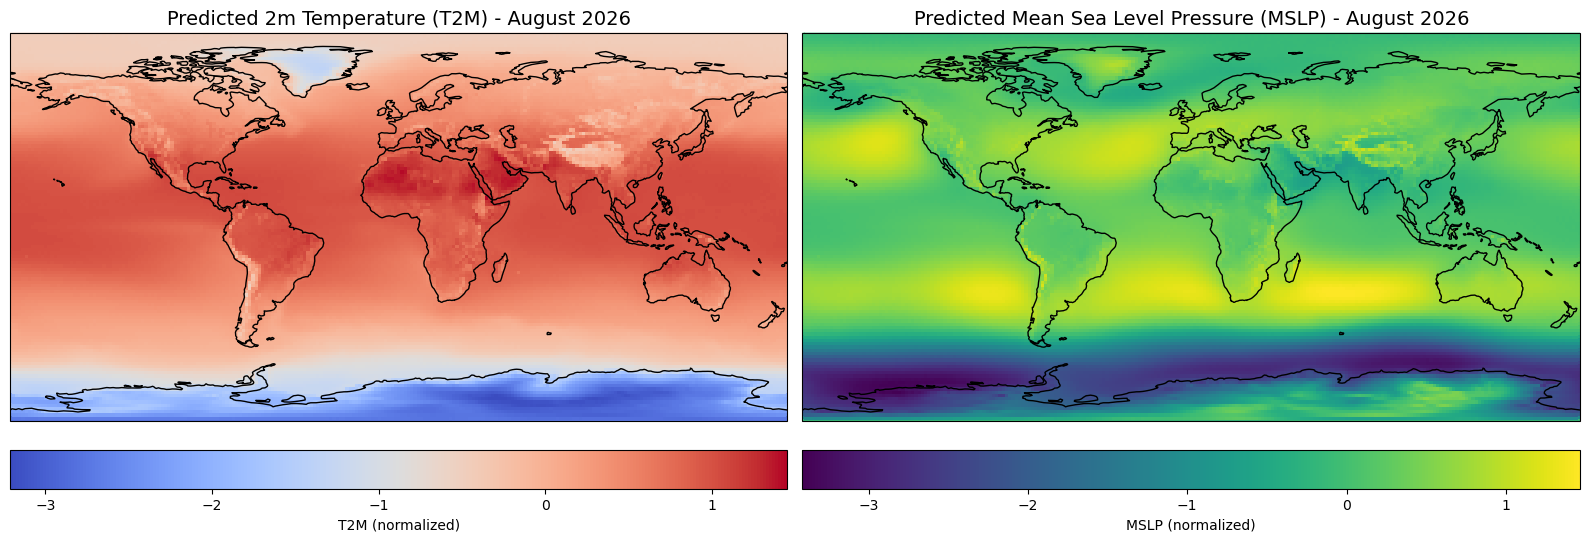

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === 加载数据 ===
file_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/预测结果-2026年8月.nc"
ds = xr.open_dataset(file_path)

t2m = ds['t2m_pred'].isel(time=0)  # (lat, lon)
msl = ds['msl_pred'].isel(time=0)
lat = ds.latitude.values
lon = ds.longitude.values

# === 创建投影图（两张子图） ===
fig = plt.figure(figsize=(16, 6))

# -- T2M --
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
t2m_plot = ax1.pcolormesh(lon, lat, t2m, cmap='coolwarm', shading='auto')
ax1.coastlines()
ax1.set_title("Predicted 2m Temperature (T2M) - August 2026", fontsize=14)
plt.colorbar(t2m_plot, ax=ax1, orientation='horizontal', pad=0.05, label="T2M (normalized)")

# -- MSLP --
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
msl_plot = ax2.pcolormesh(lon, lat, msl, cmap='viridis', shading='auto')
ax2.coastlines()
ax2.set_title("Predicted Mean Sea Level Pressure (MSLP) - August 2026", fontsize=14)
plt.colorbar(msl_plot, ax=ax2, orientation='horizontal', pad=0.05, label="MSLP (normalized)")

plt.tight_layout()
plt.show()


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === 加载数据 ===
file_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/预测结果-2026年6月.nc"
ds = xr.open_dataset(file_path)

t2m = ds['pred_t2m']  # (lat, lon)
msl = ds['pred_msl'] 
lat = ds.latitude.values
lon = ds.longitude.values

# === 创建投影图（两张子图） ===
fig = plt.figure(figsize=(16, 6))

# -- T2M --
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
t2m_plot = ax1.pcolormesh(lon, lat, t2m, cmap='coolwarm', shading='auto')
ax1.coastlines()
ax1.set_title("Predicted 2m Temperature (T2M) - July 2025", fontsize=14)
plt.colorbar(t2m_plot, ax=ax1, orientation='horizontal', pad=0.05, label="T2M (normalized)")

# -- MSLP --
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
msl_plot = ax2.pcolormesh(lon, lat, msl, cmap='viridis', shading='auto')
ax2.coastlines()
ax2.set_title("Predicted Mean Sea Level Pressure (MSLP) - July 2025", fontsize=14)
plt.colorbar(msl_plot, ax=ax2, orientation='horizontal', pad=0.05, label="MSLP (normalized)")

plt.tight_layout()
plt.show()


In [4]:
# 3 处理周数据
import os
import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm

# === 设置路径 ===
input_dir = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/数据/data"
tas_output_dir = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/tas周"
gh_output_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/obs-era5-20260831-gh.nc"
final_output_path = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/tas-hi_gh_20260831.nc"
os.makedirs(tas_output_dir, exist_ok=True)
os.makedirs(os.path.dirname(gh_output_path), exist_ok=True)

# === 插值目标网格（1.5°）===
target_lat = np.linspace(90, -90, 121)
target_lon = np.linspace(0, 358.5, 240)

# === 读取2m温度并处理为每周数据 ===
tas_file = os.path.join(input_dir, "ERA5-daily-single level-2m_Temperature-20260831.nc")
ds = xr.open_dataset(tas_file)
t2m = ds['t2m']
t2m.name = 'tas'
t2m.attrs.update({
    'units': 'K',
    'long_name': '2 metre temperature',
    'standard_name': 'air_temperature'
})
t2m_weekly = t2m.resample(valid_time='1W-MON').mean()
t2m_interp = t2m_weekly.interp(latitude=target_lat, longitude=target_lon, method='linear')

# === 每周温度数据逐步保存 ===
for i in tqdm(range(t2m_interp.valid_time.size), desc='📦 保存温度周数据'):
    da = t2m_interp.isel(valid_time=i)
    date_str = np.datetime_as_string(da.valid_time.values, unit='D').replace('-', '')
    output_path = os.path.join(tas_output_dir, f'obs-era5-{date_str}-tas.nc')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    da_ds = xr.Dataset({da.name: da.expand_dims('time')})
    da_ds = da_ds.assign_coords(time=[da.valid_time.values])
    da_ds['time'].attrs = {
        'standard_name': 'time',
        'long_name': 'time',
        'bounds': 'time_bnds',
        'axis': 'T'
    }
    da_ds['variable'] = xr.DataArray(['tas'], dims='variable')
    da_ds['variable'].attrs = {
        'long_name': 'variable name',
        'standard_name': 'variable',
    }
    da_ds.to_netcdf(output_path)

# === 读取各层位势高度并计算差值与周均 ===
def read_and_process_gh(filepath):
    ds = xr.open_dataset(filepath)
    return ds['z'].squeeze(dim='pressure_level') / 9.8

z200 = read_and_process_gh(os.path.join(input_dir, "ERA5-daily-200hpa-Geopotential-20260831.nc"))
z300 = read_and_process_gh(os.path.join(input_dir, "ERA5-daily-300hpa-Geopotential-20260831.nc"))
z500 = read_and_process_gh(os.path.join(input_dir, "ERA5-daily-500hpa-Geopotential-20260831.nc"))

z200_interp = z200.interp(latitude=target_lat, longitude=target_lon, method="linear")
z300_interp = z300.interp(latitude=target_lat, longitude=target_lon, method="linear")
z500_interp = z500.interp(latitude=target_lat, longitude=target_lon, method="linear")

z200_filled = z200_interp.ffill('latitude').bfill('latitude').ffill('longitude').bfill('longitude')
z300_filled = z300_interp.ffill('latitude').bfill('latitude').ffill('longitude').bfill('longitude')
z500_filled = z500_interp.ffill('latitude').bfill('latitude').ffill('longitude').bfill('longitude')

z200_z300 = z200_filled - z300_filled
z200_z500 = z200_filled - z500_filled

z200_weekly = z200_filled.resample(valid_time='1W-MON').mean()
z200_z300_weekly = z200_z300.resample(valid_time='1W-MON').mean()
z200_z500_weekly = z200_z500.resample(valid_time='1W-MON').mean()

ds_gh_out = xr.Dataset({
    'z200_weekly': z200_weekly,
    'z200_z300_weekly': z200_z300_weekly,
    'z200_z500_weekly': z200_z500_weekly
})
ds_gh_out.to_netcdf(gh_output_path, mode="w")
print(f"✅ 位势高度数据保存至 {gh_output_path}")

# === 合并 tas 和位势高度数据 ===
ds_gh = xr.open_dataset(gh_output_path)
if "valid_time" not in ds_gh.coords:
    raise ValueError("gh文件中缺少 valid_time 坐标")
gh_time = ds_gh["valid_time"].values
gh_map = {pd.to_datetime(t).strftime("%Y%m%d"): i for i, t in enumerate(gh_time)}

tas_files = sorted([f for f in os.listdir(tas_output_dir) if f.endswith(".nc")])
merged_datasets = []

for fname in tqdm(tas_files, desc="🔗 合并 tas 和 gh"):
    tas_path = os.path.join(tas_output_dir, fname)
    try:
        ds_tas = xr.open_dataset(tas_path)
        time_val = pd.to_datetime(str(ds_tas['time'].values[0]))
        date_str = time_val.strftime("%Y%m%d")

        if date_str not in gh_map:
            print(f"⚠️ 跳过日期 {date_str}，在gh中未找到匹配时间")
            continue

        gh_idx = gh_map[date_str]
        gh_sel = ds_gh.isel(valid_time=gh_idx).drop_vars("valid_time", errors="ignore").expand_dims(time=[time_val])
        tas_sel = ds_tas["tas"].isel(time=0).expand_dims(time=[time_val])

        ds_merged = xr.Dataset(
            data_vars={
                "tas": tas_sel,
                "z200_weekly": gh_sel["z200_weekly"],
                "z200_z300_weekly": gh_sel["z200_z300_weekly"],
                "z200_z500_weekly": gh_sel["z200_z500_weekly"],
            },
            coords={
                "time": [time_val],
                "latitude": ds_tas["latitude"],
                "longitude": ds_tas["longitude"]
            }
        )
        merged_datasets.append(ds_merged)
        ds_tas.close()

    except Exception as e:
        print(f"❌ 错误处理文件 {fname}: {e}")

# === 保存合并结果 ===
if merged_datasets:
    ds_all = xr.concat(merged_datasets, dim="time").sortby("time")
    ds_all.to_netcdf(final_output_path)
    ds_all.close()
    print(f"✅ 合并文件已保存: {final_output_path}")
else:
    print("⚠️ 没有有效的数据被合并")

📦 保存温度周数据: 100%|██████████| 24/24 [00:00<00:00, 259.51it/s]


✅ 位势高度数据保存至 /Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/obs-era5-20260831-gh.nc


🔗 合并 tas 和 gh: 100%|██████████| 24/24 [00:00<00:00, 230.84it/s]

✅ 合并文件已保存: /Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/tas-hi_gh_20260831.nc



/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_77969/555902003.py:133: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_all = xr.concat(merged_datasets, dim="time").sortby("time")


In [5]:
# 4 给周数据添加基准日期
import xarray as xr
import pandas as pd
import numpy as np
import os

# === 设置输入输出路径 ===
input_file = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/tas-hi_gh_20260831.nc"
output_dir = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/"
output_file = os.path.join(output_dir, "20260831_weekly_sample.nc")
os.makedirs(output_dir, exist_ok=True)

# === 加载数据 ===
ds = xr.open_dataset(input_file)
ds['time'] = pd.to_datetime(ds['time'].values)

# === 重命名变量便于处理 ===
ds = ds.rename({
    'z200_weekly': 'gh200',
    'z200_z300_weekly': 'gh200_300',
    'z200_z500_weekly': 'gh200_500'
})

# === 设置目标日期 ===
target_date = pd.to_datetime("2026-08-31")

# === 构造历史周数据 ===
past_20_weeks = [target_date - pd.Timedelta(weeks=i) for i in range(4, 24)]  # 20周 tas
past_10_weeks = [target_date - pd.Timedelta(weeks=i) for i in range(4, 14)]  # 10周位势高度

try:
    tas_hist_all = ds['tas'].sel(time=past_20_weeks)
    gh200_hist_all = ds['gh200'].sel(time=past_10_weeks)
    gh200_300_hist_all = ds['gh200_300'].sel(time=past_10_weeks)
    gh200_500_hist_all = ds['gh200_500'].sel(time=past_10_weeks)
except Exception as e:
    print(f"❌ 选择历史数据时出错：{e}")
    raise

# === 构造输出数据集 ===
data_vars = {}
coords = {
    "time": [target_date],
    "latitude": ds.latitude,
    "longitude": ds.longitude
}

for i in range(tas_hist_all.time.size):
    data_vars[f"tas_hist_{i}"] = (("latitude", "longitude"), tas_hist_all.isel(time=i).values)

for i in range(gh200_hist_all.time.size):
    data_vars[f"gh200_hist_{i}"] = (("latitude", "longitude"), gh200_hist_all.isel(time=i).values)

for i in range(gh200_300_hist_all.time.size):
    data_vars[f"gh200_300_hist_{i}"] = (("latitude", "longitude"), gh200_300_hist_all.isel(time=i).values)

for i in range(gh200_500_hist_all.time.size):
    data_vars[f"gh200_500_hist_{i}"] = (("latitude", "longitude"), gh200_500_hist_all.isel(time=i).values)

# === 保存结果 ===
ds_output = xr.Dataset(data_vars=data_vars, coords=coords)
ds_output.to_netcdf(output_file)
print(f"✅ 已保存到：{output_file}")


✅ 已保存到：/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample.nc


In [6]:
# 5 添加月预测数据
import xarray as xr
import numpy as np
import os

# 路径设置
weekly_sample_file = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample.nc"
pred_aug_file = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/预测结果-2026年8月.nc"

# 打开数据
ds_sample = xr.open_dataset(weekly_sample_file)
ds_pred = xr.open_dataset(pred_aug_file)

# 取预测值（只取 time=2025-08 的 t2m_pred）
t2m_pred_aug = ds_pred["t2m_pred"].squeeze()  # shape: (lat, lon)

# 创建新的 DataArray，命名为 pred_t2m_month
pred_t2m_month = xr.DataArray(
    data=t2m_pred_aug.data.astype(np.float32),
    dims=("latitude", "longitude"),
    coords={
        "latitude": ds_sample.latitude,
        "longitude": ds_sample.longitude,
    },
    name="pred_t2m_month",
    attrs={"description": "2026年8月月平均2米气温预测", "units": "K"}
)

# 添加变量到原数据集中
ds_sample["pred_t2m_month"] = pred_t2m_month

# 保存
output_file = weekly_sample_file  # 或另存为新文件以防覆盖
ds_sample.to_netcdf("/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred.nc")
print(f"✅ 成功添加并保存:/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred.nc")


✅ 成功添加并保存:/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred.nc


In [7]:
# 6 添加地形数据，最后一步
import xarray as xr
import numpy as np

# 输入文件（已有预测数据）
input_file = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred.nc"
# 地形文件
elev_file = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/地形数据/etopo_1.5deg.nc"
# 输出文件，避免覆盖
output_file = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"

# 打开数据集
ds = xr.open_dataset(input_file)
ds_elev = xr.open_dataset(elev_file)

# 将地形经度转换为0~360范围，并升序排序，方便插值
def lon_180_to_360(lon):
    lon_360 = np.where(lon < 0, lon + 360, lon)
    return lon_360

ds_elev = ds_elev.assign_coords(lon=lon_180_to_360(ds_elev.lon))
ds_elev = ds_elev.sortby('lon')

# 重命名地形坐标，匹配目标数据
ds_elev_renamed = ds_elev.rename({'lat': 'latitude', 'lon': 'longitude'})

# 插值地形数据到目标经纬度网格
ds_elev_interp = ds_elev_renamed.interp(latitude=ds.latitude, longitude=ds.longitude, method="linear")

# 将二维地形扩展到时间维度
elev_expanded = ds_elev_interp['elevation'].expand_dims({'time': ds.time}, axis=0)
elev_expanded = elev_expanded.transpose('time', 'latitude', 'longitude')

# 创建新的 DataArray 变量
elev_da = xr.DataArray(
    data=elev_expanded.values,
    dims=['time', 'latitude', 'longitude'],
    coords={'time': ds.time, 'latitude': ds.latitude, 'longitude': ds.longitude},
    attrs={
        'long_name': 'surface_elevation',
        'units': 'meters',
        'description': 'Surface elevation interpolated from etopo_1.5deg.nc and expanded along time dimension'
    }
)

# 添加到原数据集
ds = ds.assign(elevation=elev_da)

# 保存为新文件，避免覆盖
ds.to_netcdf(output_file)

print(f"添加地形数据并保存到新文件：{output_file}")

添加地形数据并保存到新文件：/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc
